In [1]:
import os
import json
import torch
import numpy as np
import pandas as pd

from omegaconf import OmegaConf
from loguru import logger as lgr_logger

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from sunpy.visualization.colormaps import color_tables

from sdofmv2.core import MAE, SDOMLDataModule, inverse_log_norm, mapping_dense_to_rgb, plot_heads, patch_attn_layers, visualize_head
from sdofmv2.utils import ALL_COMPONENTS

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
cfg = OmegaConf.load(
    "../../configs/pretrain/pretrain_mae_HMI.yaml"
    )

In [4]:
data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    frequency=cfg.data.sdoml.frequency,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    val_months=cfg.data.month_splits.val,
    test_months=cfg.data.month_splits.test,
    holdout_months=cfg.data.month_splits.holdout,
    cache_dir=os.path.join(
        "../../assets",
        cfg.data.sdoml.sub_directory.cache,
    ),
    min_date=cfg.data.min_date,
    max_date=cfg.data.max_date,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
)
data_module.setup()

[* CACHE SYSTEM *] Found cached index data in ../../assets/cache/aligndata_HMI_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-03-09 01:53:51.491 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/HMI/Bx_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:53:51.491 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/HMI/By_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:53:51.492 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/HMI/Bz_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json


[* CACHE SYSTEM *] Found cached HMI mask data in ../../assets/cache/hmi_mask_512x512.npy.


2026-03-09 01:53:52.329 | INFO     | sdofmv2.core.datamodule:setup:1070 - Train dataloader is ready!
2026-03-09 01:53:52.330 | INFO     | sdofmv2.core.datamodule:setup:1071 - Dataset size: 284813
2026-03-09 01:53:52.336 | INFO     | sdofmv2.core.datamodule:setup:1093 - Validation dataloader is ready!
2026-03-09 01:53:52.337 | INFO     | sdofmv2.core.datamodule:setup:1094 - Dataset size: 30533
2026-03-09 01:53:52.346 | INFO     | sdofmv2.core.datamodule:setup:1116 - test dataloader is ready!
2026-03-09 01:53:52.346 | INFO     | sdofmv2.core.datamodule:setup:1117 - Dataset size: 31570


In [6]:
ckpt_dir = "../../assets/check_point/backbone/"
model = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "HMI/id_mycczy8p_mae_epoch=299-val_loss=0.03.ckpt", 
    map_location="cpu",
    weights_only=False)
model.eval()

model_loss_inner_only = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "HMI/id_do2piiw5_mae_epoch=96-val_loss=0.00.ckpt", 
    map_location="cpu",
    weights_only=False)
model_loss_inner_only.eval()

MAE(
  (autoencoder): MaskedAutoencoderViT3D(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(3, 768, kernel_size=(1, 16, 16), stride=(1, 16, 16))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (drop1): Dropout(p=0.0, inplace=False)
       

In [7]:
timestamps = [
    "2011-12-25 00:12:00",
    "2012-12-25 00:12:00",
    "2013-12-25 00:12:00",
    # "2014-12-25 00:12:00",
    # "2015-12-25 00:12:00"
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

print(f"Datetime: {ts}")

Datetime: [Timestamp('2011-12-25 00:12:00'), Timestamp('2012-12-25 00:12:00'), Timestamp('2013-12-25 00:12:00')]


In [8]:
components = ALL_COMPONENTS
components.sort()

# norm information
norm_stat = {"HMI": {}}
for ch_id, ch in enumerate(components):
    
    cache_path = "../../assets/cache/HMI/"
    file_name = (
        ch
        + "_"
        + "_".join(data_module.cache_id.split("_")[-1:])
        + f"_norm-{data_module.normalization.type}"
        + ".json"
    )

    with open(cache_path + file_name, "r") as json_file:
        ch_stat = json.load(json_file)
    
    norm_stat["HMI"][ch] = ch_stat

# input/output inverse log transform for visualization
for i_img in range(x_set.shape[0]):
    for ch_id, ch in enumerate(components):

        x_set[i_img, ch_id, 0, :, :] = inverse_log_norm(
            x_set[i_img, ch_id, 0, :, :],
            norm_stat,
            "HMI",
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
            cfg.data.sdoml.normalization.scaler_div_factor
        )

In [9]:
attn_maps_1 = patch_attn_layers(model)
attn_maps_2 = patch_attn_layers(model_loss_inner_only)

with torch.no_grad():
    latent, mask, ids_restore = model.autoencoder.forward_encoder(x_set, mask_ratio=0)
    latent_inner, mask, ids_restore_inner= model_loss_inner_only.autoencoder.forward_encoder(x_set, mask_ratio=0)

In [10]:
def get_mean_pulled_head_attn(attn_maps, img_index):
    attn = attn_maps[0][img_index, :, 1:, 1:]
    num_heads = attn.shape[0]
    full_order = torch.argsort(ids_restore[img_index])  # Invert argsort
    num_kept = attn.shape[1]
    ids_keep = full_order[:num_kept]
    attn_received = attn.mean(axis=1)

    return attn_received, ids_keep

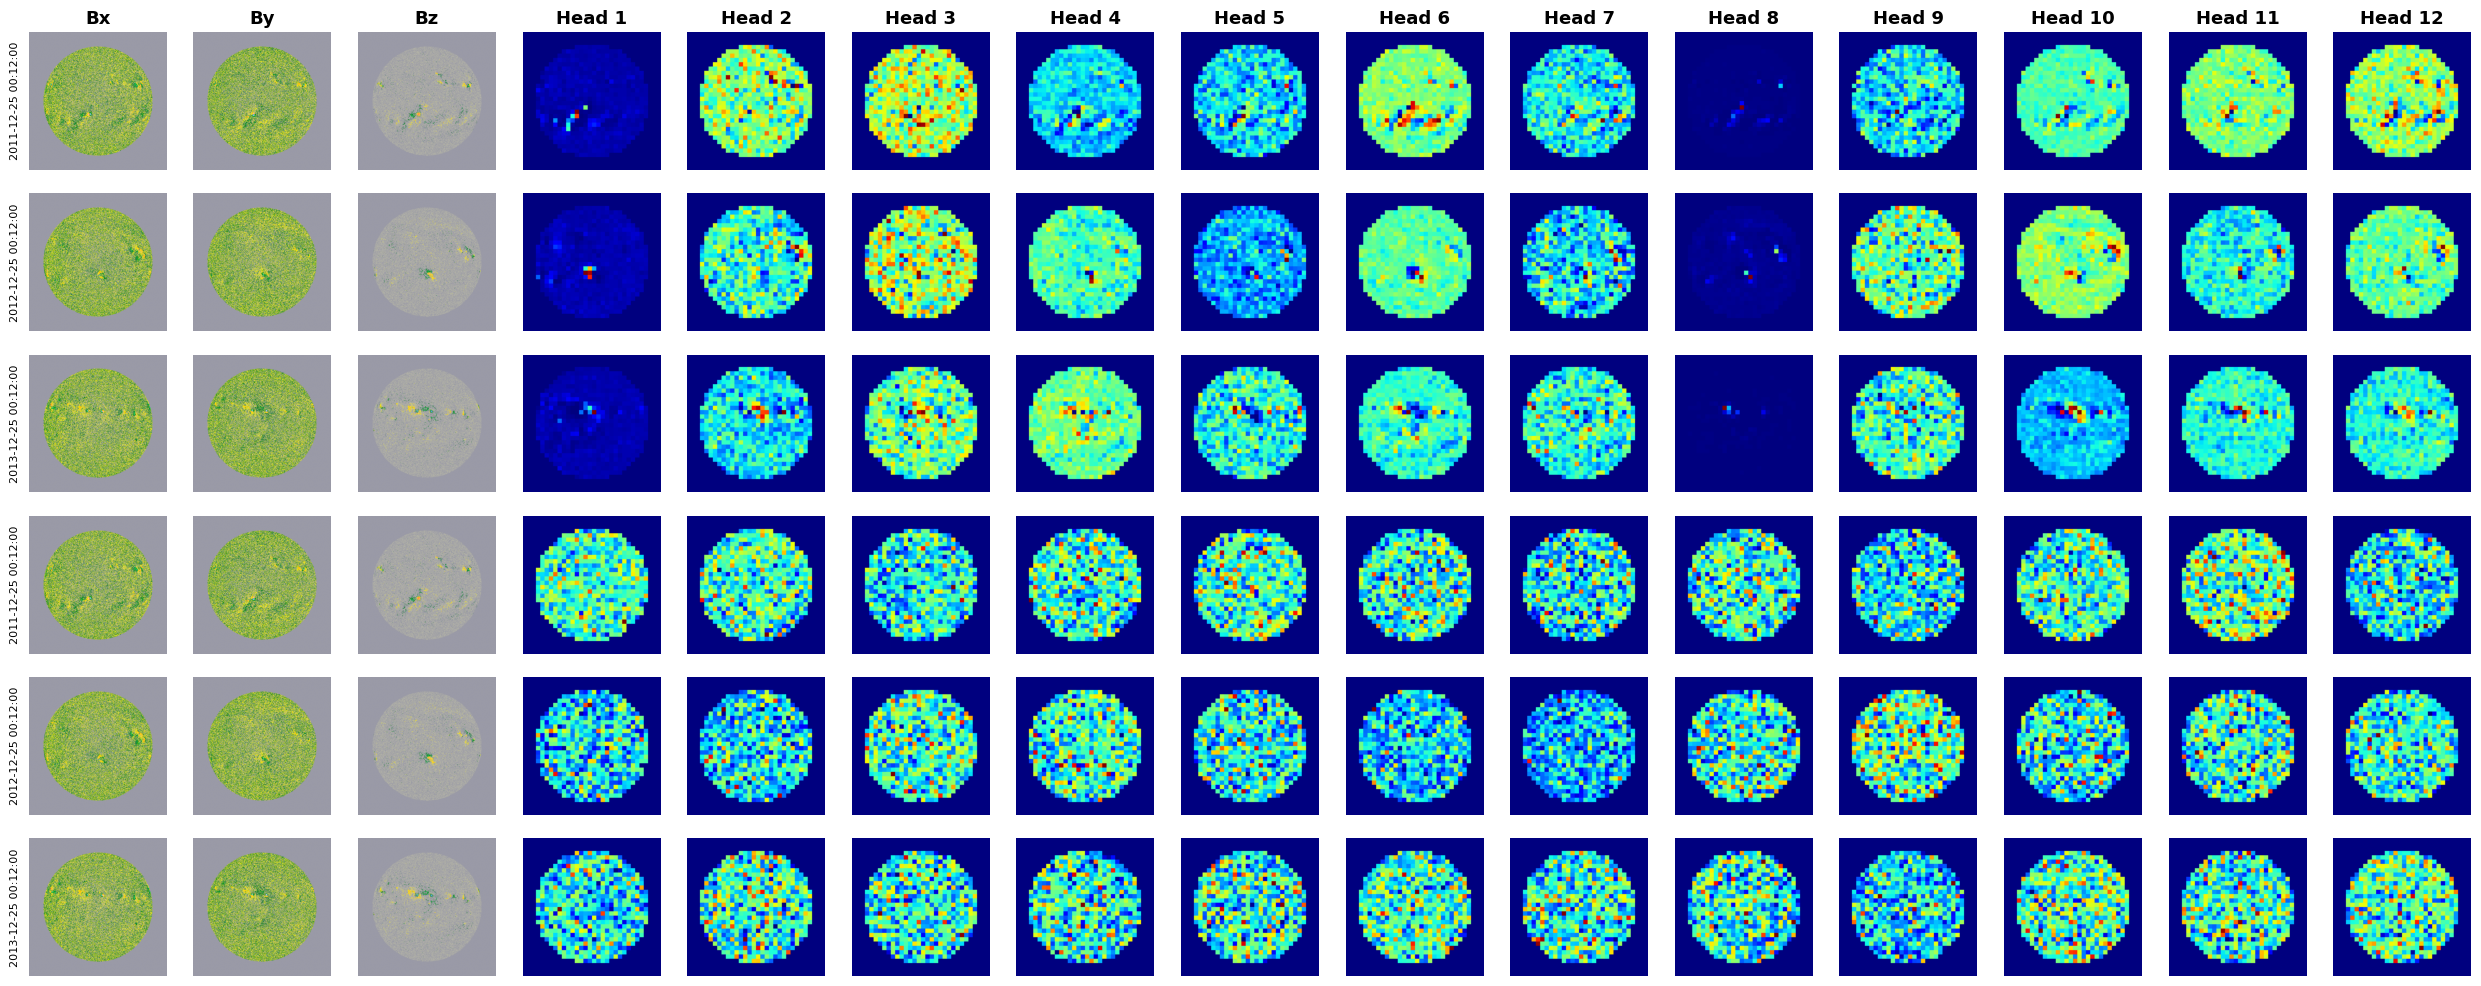

In [11]:
num_images = x_set.shape[0]
num_channels = x_set.shape[1]
num_heads = attn_maps_1[0].shape[1]
hmi_cmap= color_tables.hmi_mag_color_table()
norm = TwoSlopeNorm(vmin=-4000, vcenter=0, vmax=4000)

fig, axs = plt.subplots(
    num_images * 2, num_heads + num_channels, figsize=(25, 10), squeeze=False
)

for i in range(num_images):

    attn_received, ids_keep  = get_mean_pulled_head_attn(attn_maps_1, i)
    attn_received_inner, ids_keep_inner  = get_mean_pulled_head_attn(attn_maps_2, i)

    for i_col, ch in enumerate(components):
        if i == 0:
            axs[i, i_col].set_title(f"{ch}", fontsize=13, fontweight='bold')

        axs[i, i_col].imshow(x_set[i, i_col, 0, :, :], cmap=hmi_cmap, norm=norm)
        axs[i+num_images, i_col].imshow(x_set[i, i_col, 0, :, :], cmap=hmi_cmap, norm=norm)
        axs[i, i_col].axis("off")
        axs[i+num_images, i_col].axis("off")


    for h in range(num_heads):
        if i == 0:
            axs[i, h+num_channels].set_title(f"Head {h+1}", fontsize=13, fontweight='bold')
            
        head_attn = attn_received[h, :]
        heatmap = visualize_head(head_attn, ids_keep, 512, 16)
        axs[i, h+num_channels].imshow(heatmap, cmap="jet")
        axs[i, h+num_channels].axis("off")

        head_attn_inner = attn_received_inner[h, :]
        heatmap_inner = visualize_head(head_attn_inner, ids_keep_inner, 512, 16)
        axs[i+num_images, h+num_channels].imshow(heatmap_inner, cmap="jet")
        axs[i+num_images, h+num_channels].axis("off")

    axs[i][0].text(
        -0.1, 0.5,              # Negative x moves it to the left
        f"{ts[i]}", 
        ha='center', 
        va='center', 
        fontsize=8, 
        rotation=90,
        transform=axs[i][0].transAxes # Ensures coordinates are relative to the subplot
    )

    axs[i+num_images][0].text(
        -0.1, 0.5,              # Negative x moves it to the left
        f"{ts[i]}", 
        ha='center', 
        va='center', 
        fontsize=8, 
        rotation=90,
        transform=axs[i+num_images][0].transAxes # Ensures coordinates are relative to the subplot
    )

plt.tight_layout()
plt.savefig("attention_map_HMI.pdf", dpi=300, bbox_inches="tight")
# plt.show()

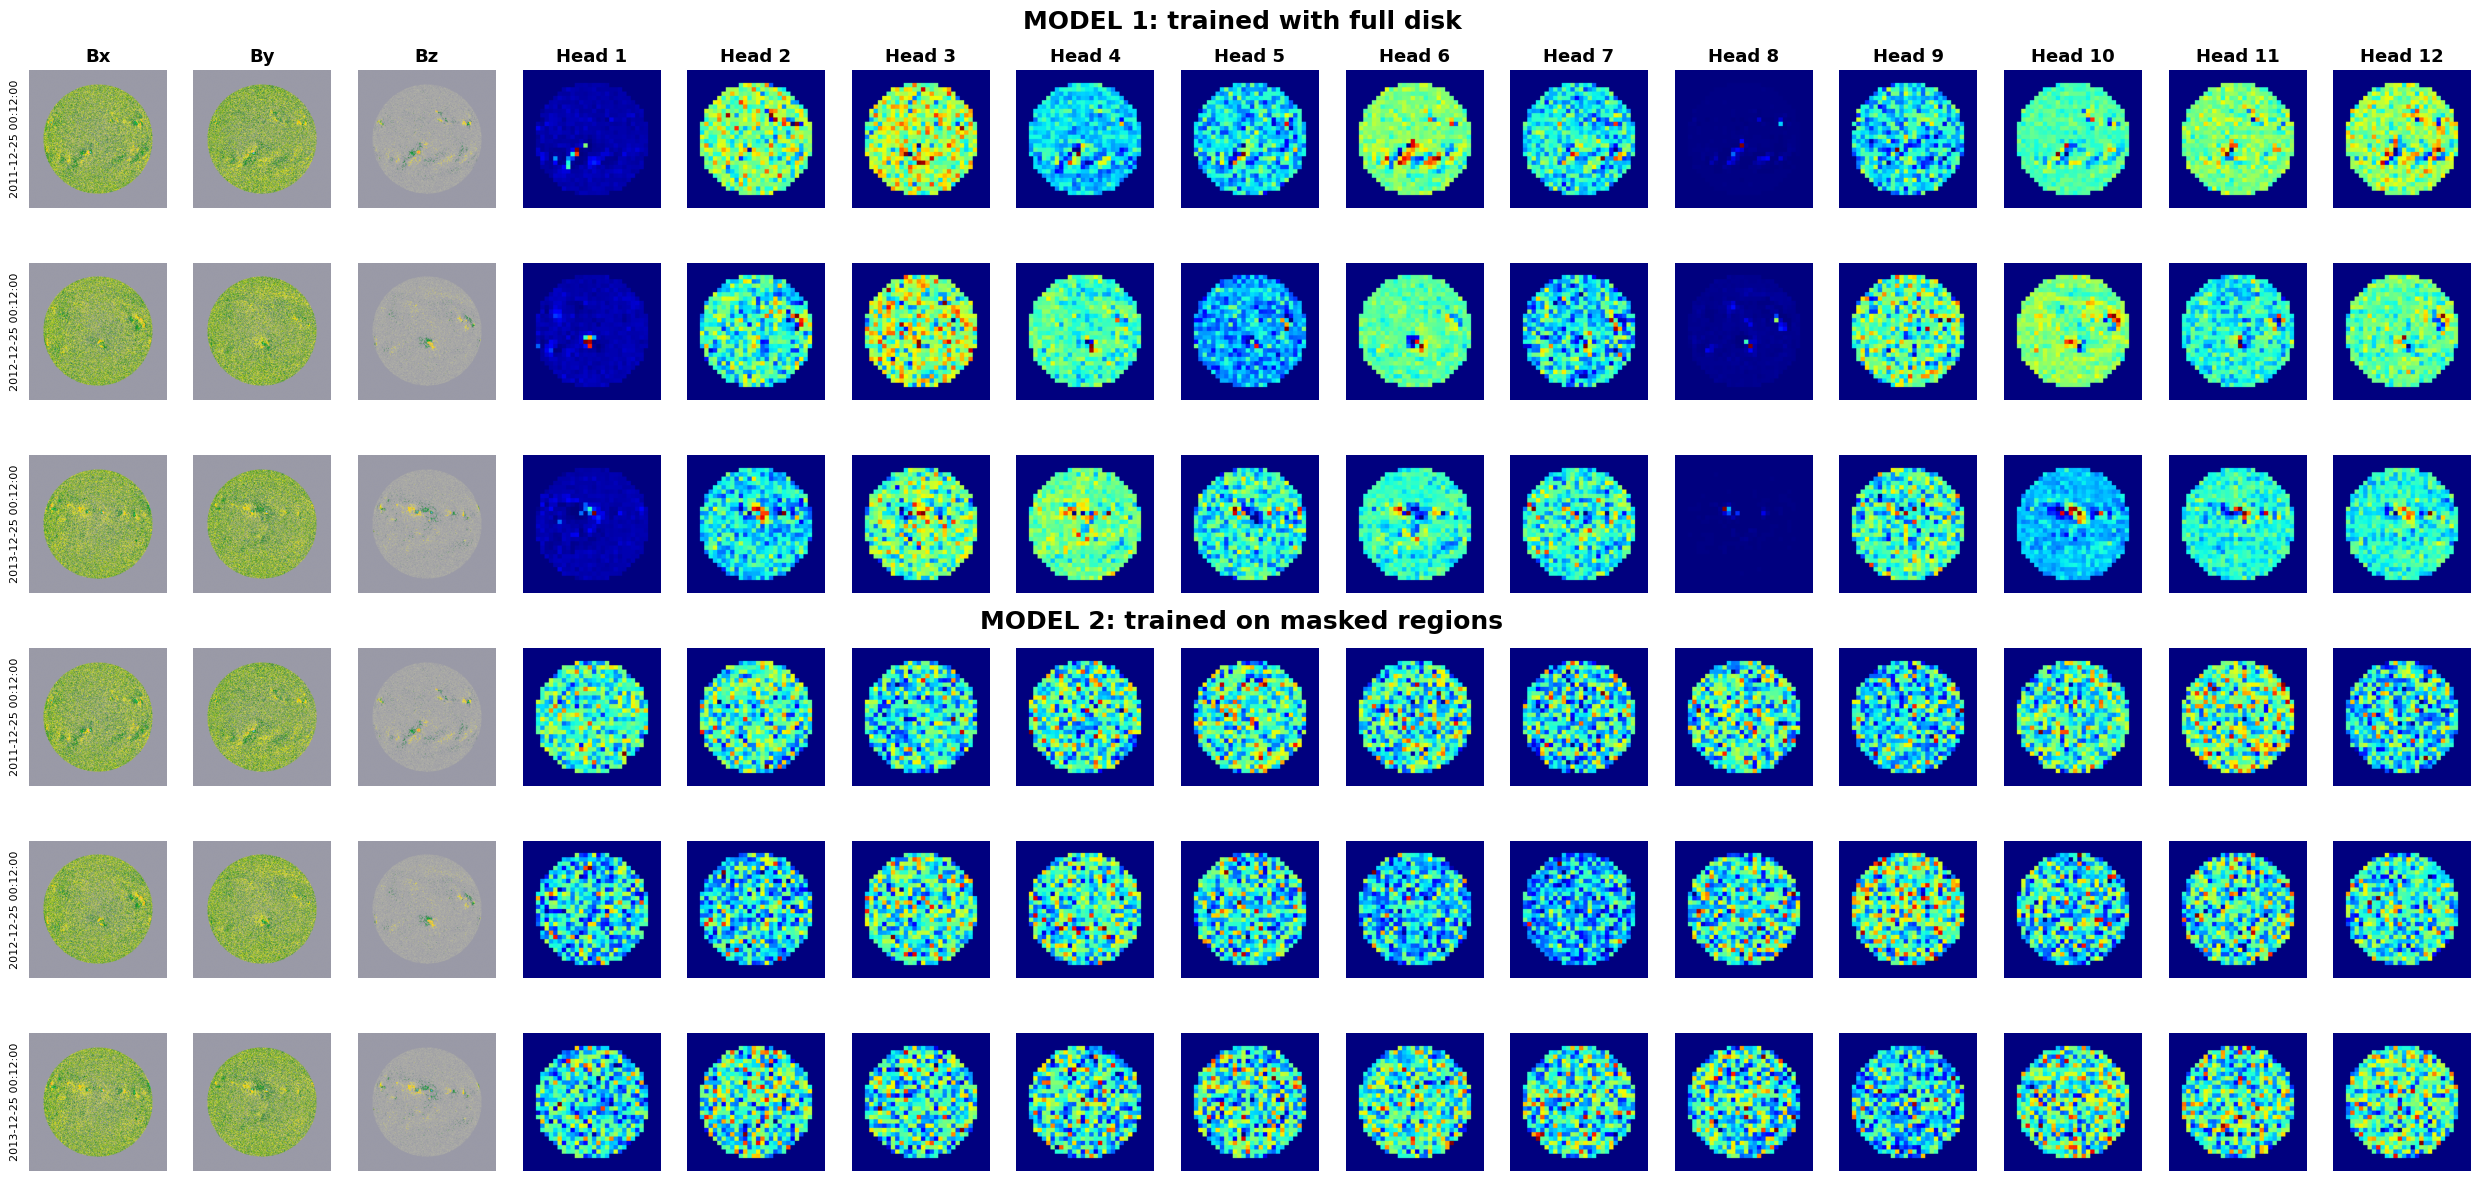

In [13]:
fig, axs = plt.subplots(
    num_images * 2, num_heads + num_channels, figsize=(25, 12), squeeze=False
)

for i in range(num_images):
    attn_received, ids_keep = get_mean_pulled_head_attn(attn_maps_1, i)
    attn_received_inner, ids_keep_inner = get_mean_pulled_head_attn(attn_maps_2, i)

    for i_col, ch in enumerate(components):
        if i == 0:
            axs[i, i_col].set_title(f"{ch}", fontsize=13, fontweight='bold')

        axs[i, i_col].imshow(x_set[i, i_col, 0, :, :], cmap=hmi_cmap, norm=norm)
        axs[i+num_images, i_col].imshow(x_set[i, i_col, 0, :, :], cmap=hmi_cmap, norm=norm)
        axs[i, i_col].axis("off")
        axs[i+num_images, i_col].axis("off")

    for h in range(num_heads):
        if i == 0:
            axs[i, h+num_channels].set_title(f"Head {h+1}", fontsize=13, fontweight='bold')
            
        head_attn = attn_received[h, :]
        heatmap = visualize_head(head_attn, ids_keep, 512, 16)
        axs[i, h+num_channels].imshow(heatmap, cmap="jet")
        axs[i, h+num_channels].axis("off")

        head_attn_inner = attn_received_inner[h, :]
        heatmap_inner = visualize_head(head_attn_inner, ids_keep_inner, 512, 16)
        axs[i+num_images, h+num_channels].imshow(heatmap_inner, cmap="jet")
        axs[i+num_images, h+num_channels].axis("off")

    # Timestamp labels
    axs[i][0].text(
        -0.1, 0.5, f"{ts[i]}", 
        ha='center', va='center', fontsize=8, rotation=90,
        transform=axs[i][0].transAxes
    )

    axs[i+num_images][0].text(
        -0.1, 0.5, f"{ts[i]}", 
        ha='center', va='center', fontsize=8, rotation=90,
        transform=axs[i+num_images][0].transAxes
    )

plt.tight_layout()
plt.subplots_adjust(top=0.93, hspace=0.4)

fig.text(
    0.5, 0.97, "MODEL 1: trained with full disk", 
    ha='center', va='center', fontsize=18, fontweight='bold'
)

fig.text(
    0.5, 0.47, "MODEL 2: trained on masked regions", 
    ha='center', va='center', fontsize=18, fontweight='bold'
)

plt.savefig("attention_map_HMI.pdf", dpi=300, bbox_inches="tight")